# NorDex Manufacturing Performance Analysis

## Week 2 — Day 1

This notebook performs exploratory data analysis on Clean Dataset Version 1. It investigates production trends, shift and machine performance, downtime, defect patterns, operational relationships and manufacturing KPIs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
project_folder = Path.cwd()

print("Notebook location:", project_folder)
print("CSV files found:")

for file in project_folder.glob("*.csv"):
    print("-", file.name)

Notebook location: c:\Users\User\AMDARI Project 1
CSV files found:
- cleaned_manufacturing_dataset_v1.csv
- extracted dataset file.csv
- raw_manufacturing_dataset.csv


In [3]:
data_file = project_folder / "raw_manufacturing_dataset.csv"

if not data_file.exists():
    raise FileNotFoundError(
        f"Could not find {data_file.name} inside {project_folder}"
    )

manufacturing_data = pd.read_csv(data_file)

print("File loaded successfully.")
print("Dataset shape:", manufacturing_data.shape)

manufacturing_data.head()

File loaded successfully.
Dataset shape: (10117, 31)


,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,operator_id,operator_name,experience_level,skill_category,machine_id,runtime_hours,downtime_minutes,maintenance_flag,machine_status,maintenance_id,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,NaN,NaN,NaN,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,NaN,NaN,NaN,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,NaN,NaN,NaN,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,NaN,NaN,NaN,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,NaN,NaN,NaN,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


In [25]:
datetime_columns = [
    "date",
    "start_datetime",
    "end_datetime",
    "timestamp"
]

for column in datetime_columns:
    if column in manufacturing_data.columns:
        manufacturing_data[column] = pd.to_datetime(
            manufacturing_data[column],
            errors="coerce"
        )

print(
    manufacturing_data[
        [
            column
            for column in datetime_columns
            if column in manufacturing_data.columns
        ]
    ].dtypes
)

date         datetime64[us]
timestamp    datetime64[us]
dtype: object


In [26]:
manufacturing_data["good_units"] = (
    manufacturing_data["units_produced"]
    - manufacturing_data["defect_count"]
)

manufacturing_data["defect_rate_pct"] = (
    manufacturing_data["defect_count"]
    / manufacturing_data["units_produced"]
    * 100
)

manufacturing_data["planned_time_hours"] = (
    manufacturing_data["runtime_hours"]
    + manufacturing_data["downtime_minutes"] / 60
)

manufacturing_data["downtime_percentage"] = (
    manufacturing_data["downtime_minutes"]
    / (
        manufacturing_data["runtime_hours"] * 60
        + manufacturing_data["downtime_minutes"]
    )
    * 100
)

manufacturing_data["machine_utilization_pct"] = (
    manufacturing_data["runtime_hours"] / 8 * 100
).clip(0, 100)

print("Analytical variables created successfully.")

Analytical variables created successfully.


In [27]:
ideal_cycle_time = (
    manufacturing_data["cycle_time_avg"].min()
)

manufacturing_data["availability_pct"] = (
    manufacturing_data["runtime_hours"]
    / manufacturing_data["planned_time_hours"]
    * 100
).clip(0, 100)

manufacturing_data["performance_pct"] = (
    ideal_cycle_time
    / manufacturing_data["cycle_time_avg"]
    * 100
).clip(0, 100)

manufacturing_data["quality_pct"] = (
    manufacturing_data["good_units"]
    / manufacturing_data["units_produced"]
    * 100
).clip(0, 100)

manufacturing_data["estimated_oee_pct"] = (
    manufacturing_data["availability_pct"] / 100
    * manufacturing_data["performance_pct"] / 100
    * manufacturing_data["quality_pct"] / 100
    * 100
)

print(
    "Temporary ideal cycle-time benchmark:",
    ideal_cycle_time
)

Temporary ideal cycle-time benchmark: 32.0


In [28]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total production output",
        "Total good units",
        "Average shift efficiency (%)",
        "Average estimated OEE (%)",
        "Average machine utilisation (%)",
        "Average downtime percentage (%)",
        "Average defect rate (%)"
    ],
    "Result": [
        manufacturing_data["units_produced"].sum(),
        manufacturing_data["good_units"].sum(),
        manufacturing_data[
            "shift_efficiency_score"
        ].mean(),
        manufacturing_data[
            "estimated_oee_pct"
        ].mean(),
        manufacturing_data[
            "machine_utilization_pct"
        ].mean(),
        manufacturing_data[
            "downtime_percentage"
        ].mean(),
        manufacturing_data[
            "defect_rate_pct"
        ].mean()
    ]
})

kpi_summary["Result"] = (
    kpi_summary["Result"].round(2)
)

kpi_summary

,KPI,Result
0,Total production output,6652863.00
1,Total good units,6436838.00
2,Average shift efficiency (%),79.04
3,Average estimated OEE (%),79.09
4,Average machine utilisation (%),86.28
5,Average downtime percentage (%),7.97
6,Average defect rate (%),3.46


In [29]:
daily_performance = (
    manufacturing_data
    .groupby("date")
    .agg(
        total_units=("units_produced", "sum"),
        total_good_units=("good_units", "sum"),
        total_defects=("defect_count", "sum"),
        average_efficiency=(
            "shift_efficiency_score",
            "mean"
        ),
        average_downtime=(
            "downtime_minutes",
            "mean"
        ),
        average_oee=(
            "estimated_oee_pct",
            "mean"
        )
    )
    .round(2)
    .reset_index()
)

daily_performance

,date,total_units,total_good_units,total_defects,average_efficiency,average_downtime,average_oee
0,2024-01-01,2299293,2224863,74430,79.28,35.83,78.76
1,2024-01-02,2227519,2154327,73192,78.57,35.93,78.73
2,2024-01-03,2126051,2057648,68403,79.29,35.80,79.83


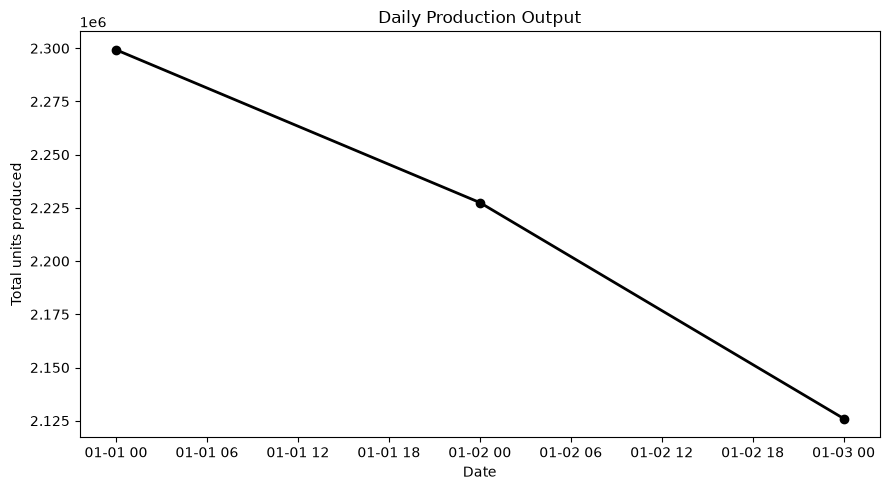

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    daily_performance["date"],
    daily_performance["total_units"],
    marker="o",
    linewidth=2,
    color="black"
)

ax.set_title("Daily Production Output")
ax.set_xlabel("Date")
ax.set_ylabel("Total units produced")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [31]:
shift_performance = (
    manufacturing_data
    .groupby("shift_name")
    .agg(
        records=("shift_id", "size"),
        total_units=("units_produced", "sum"),
        average_units=("units_produced", "mean"),
        average_defects=("defect_count", "mean"),
        average_defect_rate=(
            "defect_rate_pct",
            "mean"
        ),
        average_efficiency=(
            "shift_efficiency_score",
            "mean"
        ),
        average_downtime=(
            "downtime_minutes",
            "mean"
        ),
        average_oee=(
            "estimated_oee_pct",
            "mean"
        )
    )
    .round(2)
    .sort_values(
        "average_efficiency",
        ascending=False
    )
)

shift_performance

,records,total_units,average_units,average_defects,average_defect_rate,average_efficiency,average_downtime,average_oee
shift_name,,,,,,,,
Morning,3062,2673496,873.12,19.32,2.22,94.38,15.54,84.19
Evening,3503,2183905,623.44,22.09,3.54,80.53,35.85,78.34
Night,3552,1795462,505.48,22.38,4.45,64.35,53.37,75.44


In [ ]:
shift_order = (
    shift_performance
    .sort_values("average_efficiency")
    .index
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=manufacturing_data,
    x="shift_name",
    y="shift_efficiency_score",
    order=shift_order,
    color="gray",
    errorbar=None
)

plt.title("Average Efficiency Score by Shift")
plt.xlabel("Shift")
plt.ylabel("Average efficiency score")

plt.tight_layout()
plt.show()

NameError: name 'sns' is not defined

<Figure size 800x500 with 0 Axes>

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Seaborn imported successfully.")

Seaborn imported successfully.


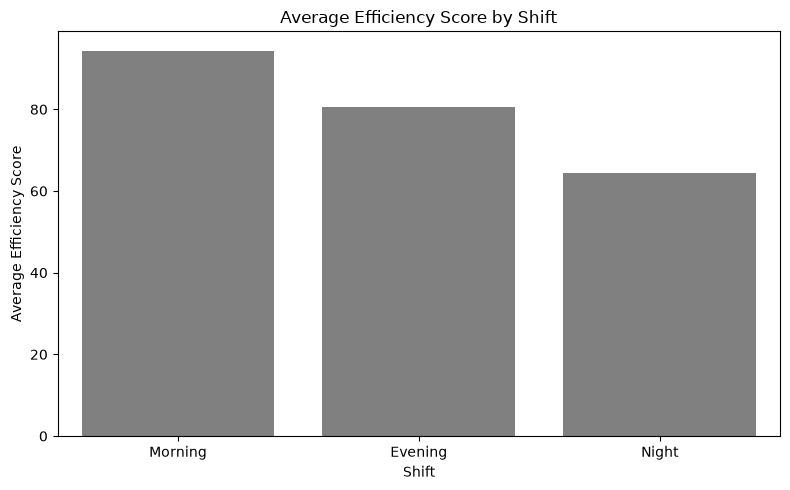

In [34]:
shift_order = (
    shift_performance
    .sort_values(
        "average_efficiency",
        ascending=False
    )
    .index
    .tolist()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=manufacturing_data,
    x="shift_name",
    y="shift_efficiency_score",
    order=shift_order,
    color="gray",
    errorbar=None
)

plt.title("Average Efficiency Score by Shift")
plt.xlabel("Shift")
plt.ylabel("Average Efficiency Score")

plt.tight_layout()
plt.show()

In [35]:
machine_performance = (
    manufacturing_data
    .groupby("machine_id")
    .agg(
        records=("production_id", "size"),
        total_units=("units_produced", "sum"),
        average_units=("units_produced", "mean"),
        total_defects=("defect_count", "sum"),
        average_defect_rate=(
            "defect_rate_pct",
            "mean"
        ),
        average_efficiency=(
            "shift_efficiency_score",
            "mean"
        ),
        average_downtime=(
            "downtime_minutes",
            "mean"
        ),
        average_utilization=(
            "machine_utilization_pct",
            "mean"
        ),
        average_oee=(
            "estimated_oee_pct",
            "mean"
        )
    )
    .round(2)
)

machine_performance.sort_values(
    "average_efficiency",
    ascending=False
).head(10)

,records,total_units,average_units,total_defects,average_defect_rate,average_efficiency,average_downtime,average_utilization,average_oee
machine_id,,,,,,,,,
MC_010,187,126335,675.59,3937,3.24,83.67,36.73,86.11,79.96
MC_021,242,159984,661.09,4974,3.27,82.66,38.21,85.79,74.06
MC_035,178,117943,662.60,3604,3.26,81.21,36.20,86.19,79.98
MC_026,192,126332,657.98,4166,3.47,81.04,36.10,86.23,81.02
MC_008,203,137911,679.36,4663,3.58,81.04,34.40,86.57,78.49
MC_004,176,115070,653.81,3494,3.21,81.02,35.03,86.44,79.32
MC_015,305,208175,682.54,6227,3.17,80.94,34.46,86.58,79.66
MC_018,183,124883,682.42,3779,3.19,80.72,34.42,86.58,78.02
MC_023,185,118015,637.92,3849,3.42,80.63,36.21,86.20,78.55


In [36]:
lowest_performing_machines = (
    machine_performance
    .sort_values(
        "average_efficiency",
        ascending=True
    )
    .head(10)
)

lowest_performing_machines

,records,total_units,average_units,total_defects,average_defect_rate,average_efficiency,average_downtime,average_utilization,average_oee
machine_id,,,,,,,,,
MC_048,177,109553,618.94,3565,3.51,75.83,38.84,85.65,78.49
MC_041,305,191678,628.45,6329,3.54,76.18,37.58,85.93,77.22
MC_033,197,128256,651.05,4425,3.77,76.57,37.14,86.00,79.61
MC_013,181,118746,656.06,3679,3.35,76.77,36.54,86.12,81.92
MC_045,186,121713,654.37,3896,3.45,76.91,35.11,86.44,78.76
MC_047,184,119748,650.80,3856,3.46,77.12,37.91,85.86,81.63
MC_011,186,122713,659.75,3876,3.38,77.16,38.08,85.79,79.27
MC_005,198,129729,655.20,4414,3.64,77.54,36.56,86.12,82.11
MC_006,169,111776,661.40,3197,3.11,77.60,34.48,86.55,79.54


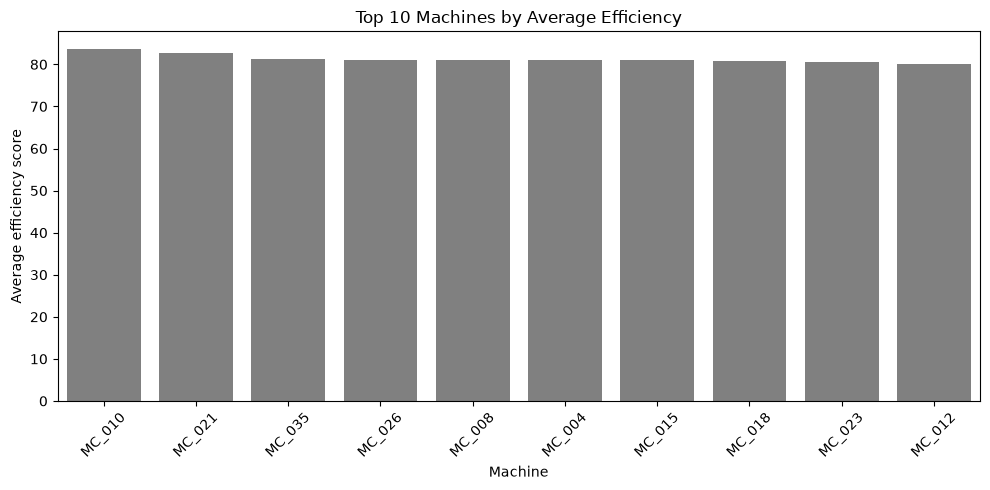

In [37]:
machine_chart_data = (
    machine_performance
    .sort_values(
        "average_efficiency",
        ascending=False
    )
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=machine_chart_data,
    x="machine_id",
    y="average_efficiency",
    color="gray"
)

plt.title(
    "Top 10 Machines by Average Efficiency"
)
plt.xlabel("Machine")
plt.ylabel("Average efficiency score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [38]:
downtime_by_shift = (
    manufacturing_data
    .groupby("shift_name")
    .agg(
        average_downtime=(
            "downtime_minutes",
            "mean"
        ),
        median_downtime=(
            "downtime_minutes",
            "median"
        ),
        maximum_downtime=(
            "downtime_minutes",
            "max"
        ),
        average_downtime_percentage=(
            "downtime_percentage",
            "mean"
        )
    )
    .round(2)
    .sort_values(
        "average_downtime",
        ascending=False
    )
)

downtime_by_shift

,average_downtime,median_downtime,maximum_downtime,average_downtime_percentage
shift_name,,,,
Night,53.37,52.95,70.43,11.86
Evening,35.85,35.58,48.40,7.97
Morning,15.54,14.87,25.86,3.45


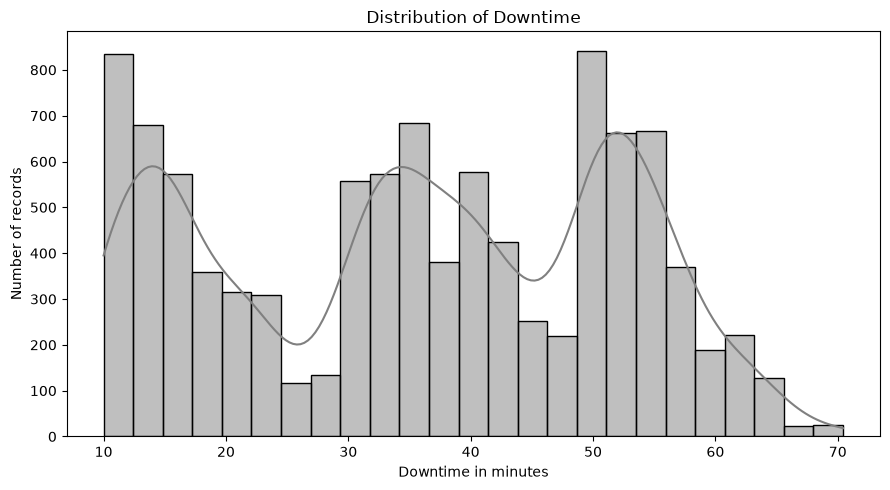

In [39]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=manufacturing_data,
    x="downtime_minutes",
    bins=25,
    kde=True,
    color="gray"
)

plt.title("Distribution of Downtime")
plt.xlabel("Downtime in minutes")
plt.ylabel("Number of records")

plt.tight_layout()
plt.show()

In [40]:
status_performance = (
    manufacturing_data
    .groupby("machine_status")
    .agg(
        records=("machine_status", "size"),
        average_units=("units_produced", "mean"),
        average_efficiency=(
            "shift_efficiency_score",
            "mean"
        ),
        average_downtime=(
            "downtime_minutes",
            "mean"
        ),
        average_oee=(
            "estimated_oee_pct",
            "mean"
        )
    )
    .round(2)
)

status_performance

,records,average_units,average_efficiency,average_downtime,average_oee
machine_status,,,,,
Issues,3503,508.93,64.92,53.72,75.38
Operational,6614,736.33,86.52,26.39,81.06


In [41]:
defect_summary = (
    manufacturing_data
    .groupby("defect_type")
    .agg(
        record_count=("defect_type", "size"),
        total_defects=("defect_count", "sum"),
        average_defects=("defect_count", "mean"),
        average_defect_rate=(
            "defect_rate_pct",
            "mean"
        )
    )
    .round(2)
    .sort_values(
        "total_defects",
        ascending=False
    )
)

defect_summary

,record_count,total_defects,average_defects,average_defect_rate
defect_type,,,,
Surface,2047,43888,21.44,3.46
Dimensional,2028,43147,21.28,3.45
Material,2014,43143,21.42,3.48
Cosmetic,2024,43138,21.31,3.45
Assembly,2004,42709,21.31,3.46


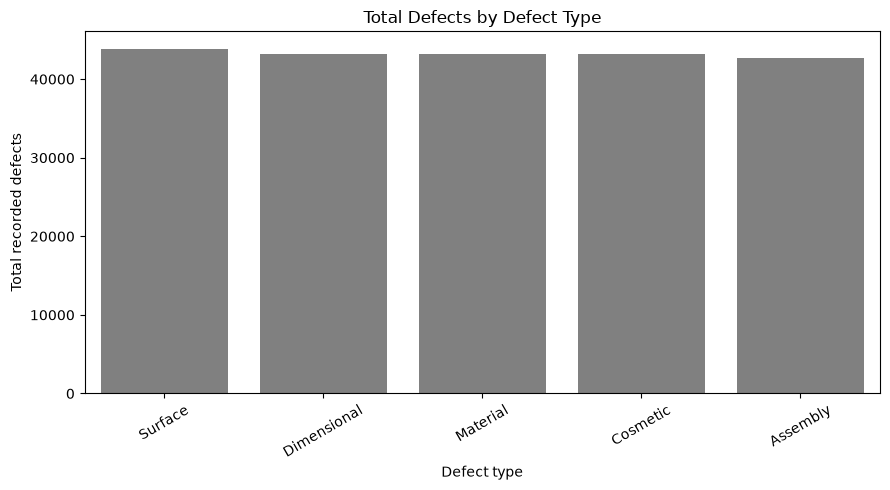

In [42]:
defect_chart_data = (
    defect_summary
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=defect_chart_data,
    x="defect_type",
    y="total_defects",
    color="gray"
)

plt.title("Total Defects by Defect Type")
plt.xlabel("Defect type")
plt.ylabel("Total recorded defects")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [43]:
inspection_summary = (
    manufacturing_data[
        "inspection_result"
    ]
    .value_counts()
    .rename_axis("inspection_result")
    .reset_index(name="record_count")
)

inspection_summary["percentage"] = (
    inspection_summary["record_count"]
    / len(manufacturing_data)
    * 100
).round(2)

inspection_summary

,inspection_result,record_count,percentage
0,Rework,5850,57.82
1,Accepted,2194,21.69
2,Rejected,2073,20.49


In [44]:
correlation_columns = [
    "units_produced",
    "defect_count",
    "cycle_time_avg",
    "shift_efficiency_score",
    "runtime_hours",
    "downtime_minutes",
    "temperature",
    "humidity",
    "defect_rate_pct",
    "machine_utilization_pct",
    "estimated_oee_pct"
]

correlation_matrix = (
    manufacturing_data[
        correlation_columns
    ]
    .corr()
    .round(2)
)

correlation_matrix

,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,runtime_hours,downtime_minutes,temperature,humidity,defect_rate_pct,machine_utilization_pct,estimated_oee_pct
units_produced,1.00,-0.44,0.02,0.93,0.93,-0.93,0.14,-0.42,-0.90,0.93,0.61
defect_count,-0.44,1.00,-0.00,-0.40,-0.37,0.38,-0.15,0.19,0.75,-0.37,-0.31
cycle_time_avg,0.02,-0.00,1.00,0.05,0.03,-0.03,-0.12,0.01,-0.03,0.03,-0.75
shift_efficiency_score,0.93,-0.40,0.05,1.00,0.92,-0.92,-0.02,-0.50,-0.88,0.92,0.58
runtime_hours,0.93,-0.37,0.03,0.92,1.00,-1.00,0.04,-0.47,-0.84,1.00,0.64
downtime_minutes,-0.93,0.38,-0.03,-0.92,-1.00,1.00,-0.04,0.47,0.84,-1.00,-0.64
temperature,0.14,-0.15,-0.12,-0.02,0.04,-0.04,1.00,-0.12,-0.08,0.04,0.13
humidity,-0.42,0.19,0.01,-0.50,-0.47,0.47,-0.12,1.00,0.43,-0.47,-0.32
defect_rate_pct,-0.90,0.75,-0.03,-0.88,-0.84,0.84,-0.08,0.43,1.00,-0.84,-0.57
machine_utilization_pct,0.93,-0.37,0.03,0.92,1.00,-1.00,0.04,-0.47,-0.84,1.00,0.64


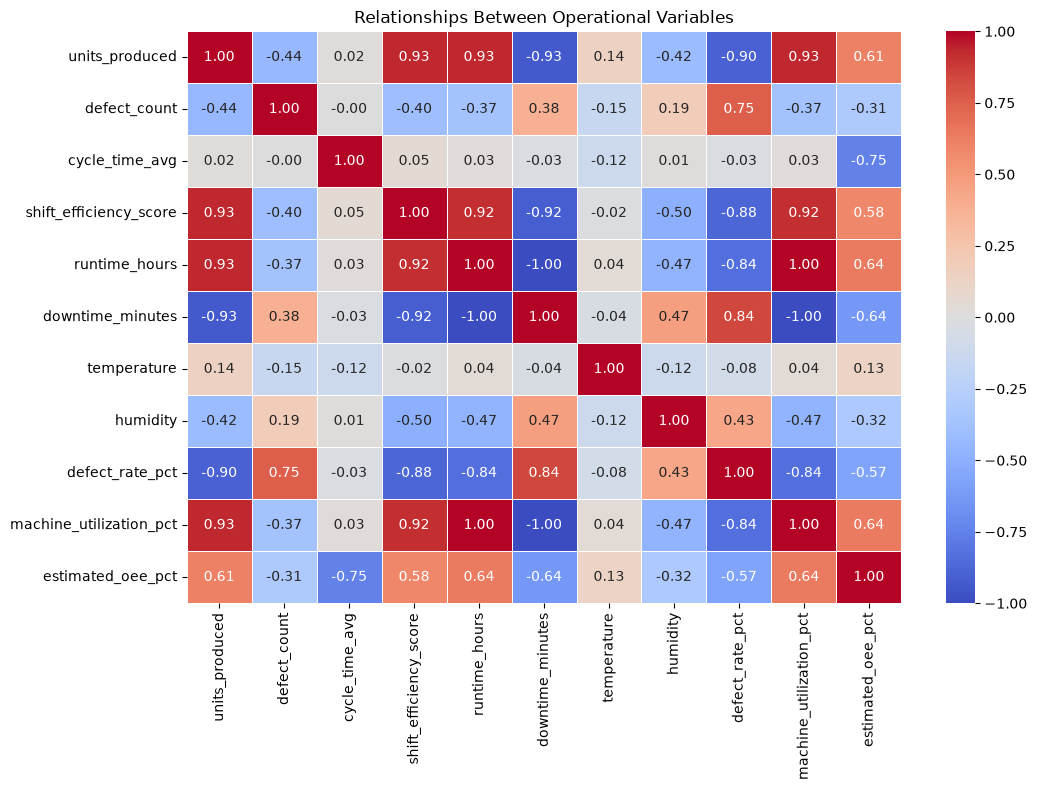

In [45]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Relationships Between Operational Variables"
)

plt.tight_layout()
plt.show()

In [46]:
efficiency_relationships = (
    correlation_matrix[
        "shift_efficiency_score"
    ]
    .drop("shift_efficiency_score")
    .sort_values(
        key=abs,
        ascending=False
    )
    .to_frame("correlation_with_efficiency")
)

efficiency_relationships

,correlation_with_efficiency
units_produced,0.93
runtime_hours,0.92
machine_utilization_pct,0.92
downtime_minutes,-0.92
defect_rate_pct,-0.88
estimated_oee_pct,0.58
humidity,-0.50
defect_count,-0.40
cycle_time_avg,0.05
temperature,-0.02


In [47]:
best_shift = (
    shift_performance[
        "average_efficiency"
    ].idxmax()
)

highest_output_shift = (
    shift_performance[
        "total_units"
    ].idxmax()
)

highest_downtime_shift = (
    downtime_by_shift[
        "average_downtime"
    ].idxmax()
)

best_machine = (
    machine_performance[
        "average_efficiency"
    ].idxmax()
)

lowest_machine = (
    machine_performance[
        "average_efficiency"
    ].idxmin()
)

most_common_defect = (
    defect_summary[
        "total_defects"
    ].idxmax()
)

In [48]:
final_findings = pd.DataFrame({
    "Area": [
        "Highest-efficiency shift",
        "Highest-output shift",
        "Highest-downtime shift",
        "Highest-efficiency machine",
        "Lowest-efficiency machine",
        "Most frequent defect type",
        "Average estimated OEE",
        "Average machine utilisation",
        "Average downtime percentage"
    ],

    "Finding": [
        best_shift,
        highest_output_shift,
        highest_downtime_shift,
        best_machine,
        lowest_machine,
        most_common_defect,
        (
            f"{manufacturing_data['estimated_oee_pct'].mean():.2f}%"
        ),
        (
            f"{manufacturing_data['machine_utilization_pct'].mean():.2f}%"
        ),
        (
            f"{manufacturing_data['downtime_percentage'].mean():.2f}%"
        )
    ]
})

final_findings

,Area,Finding
0,Highest-efficiency shift,Morning
1,Highest-output shift,Morning
2,Highest-downtime shift,Night
3,Highest-efficiency machine,MC_010
4,Lowest-efficiency machine,MC_048
5,Most frequent defect type,Surface
6,Average estimated OEE,79.09%
7,Average machine utilisation,86.28%
8,Average downtime percentage,7.97%


In [ ]:
output_workbook = Path(
    "week2_day1_eda_tables.xlsx"
)

with pd.ExcelWriter(
    output_workbook,
    engine="openpyxl"
) as writer:

    kpi_summary.to_excel(
        writer,
        sheet_name="KPI Summary",
        index=False
    )

    daily_performance.to_excel(
        writer,
        sheet_name="Daily Performance",
        index=False
    )

    shift_performance.to_excel(
        writer,
        sheet_name="Shift Performance"
    )

    machine_performance.to_excel(
        writer,
        sheet_name="Machine Performance"
    )

    downtime_by_shift.to_excel(
        writer,
        sheet_name="Downtime"
    )

    defect_summary.to_excel(
        writer,
        sheet_name="Defects"
    )

    correlation_matrix.to_excel(
        writer,
        sheet_name="Correlations"
    )

    final_findings.to_excel(
        writer,
        sheet_name="Final Findings",
        index=False
    )

print("Workbook saved:", output_workbook)
print("File exists:", output_workbook.exists())

Workbook saved: week2_day1_eda_tables.xlsx
File exists: True


: 